<a href="https://colab.research.google.com/github/suyz1213/cs666student/blob/main/CS666_Assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

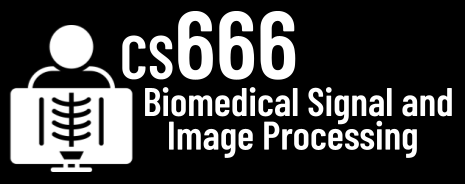

# Assignment 1

In [2]:
%pylab inline

Populating the interactive namespace from numpy and matplotlib


**Task 1** (5 pts): Install the BioSPPY library with the following code.

In [3]:
!pip install biosppy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.5/159.5 kB 3.9 MB/s eta 0:00:00


**Task 2** (10 pts): Download a sample ecg dataset from https://cs666.org/data/ecg.txt and upload it to this colab. The following code loads the dataset. Note: this might fail with an import error, but should be an easy fix :)

In [4]:
!wget https://cs666.org/data/ecg.txt

--2026-02-18 02:48:51--  https://cs666.org/data/ecg.txt
Resolving cs666.org (cs666.org)... 185.199.110.153, 185.199.111.153, 185.199.108.153, ...
Connecting to cs666.org (cs666.org)|185.199.110.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 105085 (103K) [text/plain]
Saving to: ‘ecg.txt’

ecg.txt             100%[===================>] 102.62K  --.-KB/s    in 0.01s   

2026-02-18 02:48:51 (6.91 MB/s) - ‘ecg.txt’ saved [105085/105085]



In [5]:
!pip install peakutils

In [6]:
from biosppy import storage
signal, metadata = storage.load_txt('ecg.txt')

In [7]:
metadata

{'sampling_rate': 1000.0, 'resolution': 12, 'labels': ['ECG']}

**Task 3** (10 pts): Figure out the sampling rate for this data and how many seconds it lasts.

In [8]:
SAMPLING_RATE = 1000 ### TODO!
SECONDS = len(signal) / SAMPLING_RATE ### TODO!
print("Sampling rate is ", SAMPLING_RATE, "Hz")
print("The duration is ", SECONDS, "seconds")

Sampling rate is  1000 Hz
The duration is  15.0 seconds


**Task 4** (15 pts): Process the signal with BioSPPY using the `ecg.ecg` method.

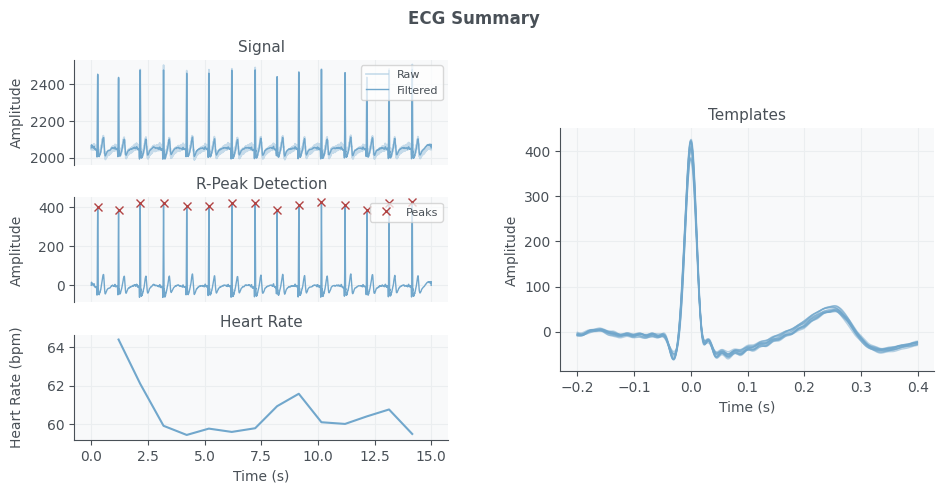

In [9]:
### TODO
from biosppy.signals import ecg
out = ecg.ecg(signal=signal, sampling_rate=SAMPLING_RATE, show=True)

In [10]:
print('rpeaks: ', out['rpeaks'])
print('#rpeaks: ', len(out['rpeaks']))

rpeaks:  [  283  1204  2159  3188  4211  5188  6200  7232  8200  9157 10156 11198
 12159 13139 14162]
#rpeaks:  15


**Task 5** (10 pts): Plot the first 3 seconds of the unfiltered signal and then the filtered signal. Can you spot the P, Q, R, S, T waves?

In [11]:
num_samples = int(3*SAMPLING_RATE)
signals_3s = signal[:num_samples]
t = np.arange(num_samples) / SAMPLING_RATE

Text(0, 0.5, 'Amplitude')

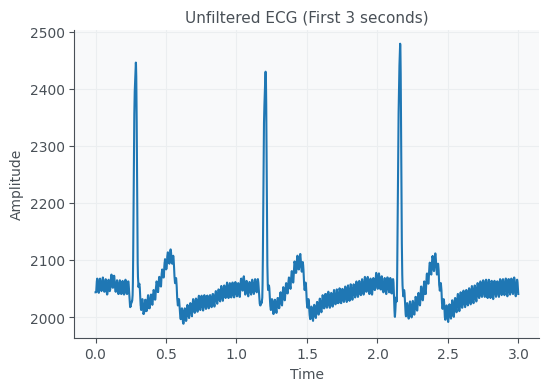

In [12]:
### TODO plot unfiltered signal
plt.figure(figsize=(6, 4))
plt.plot(t, signals_3s)
plt.title("Unfiltered ECG (First 3 seconds)")
plt.xlabel("Time")
plt.ylabel("Amplitude")

Text(0, 0.5, 'Amplitude')

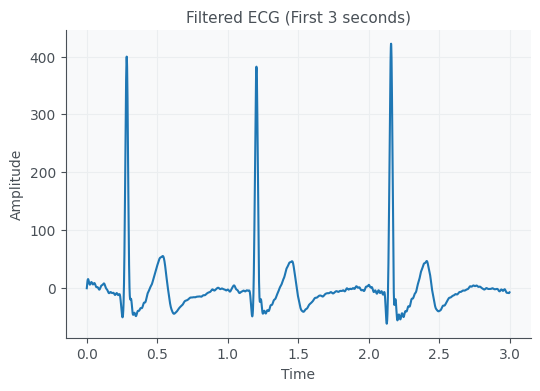

In [13]:
### TODO plot filtered signal
filtered_signals_3s = out['filtered'][:num_samples]

plt.figure(figsize=(6, 4))
plt.plot(t, filtered_signals_3s)
plt.title("Filtered ECG (First 3 seconds)")
plt.xlabel("Time")
plt.ylabel("Amplitude")

Yes, I can spot these five waves. R wave is the highest sharp peak. Q and S are small negative deflections around R. T wave appears as a broader wave after the QRS complex and P wave is smaller than T before the QRS complex.

**Task 6** (15 pts): Please plot the whole filtered signal and mark the r-peaks with vertical lines based on the ecg.ecg output. You can use `plt.axvline(x = 100, color = 'r', ls=':')` to create a red, dashed vertical line at position 100. Please label the x-axis as 'time [s]'.

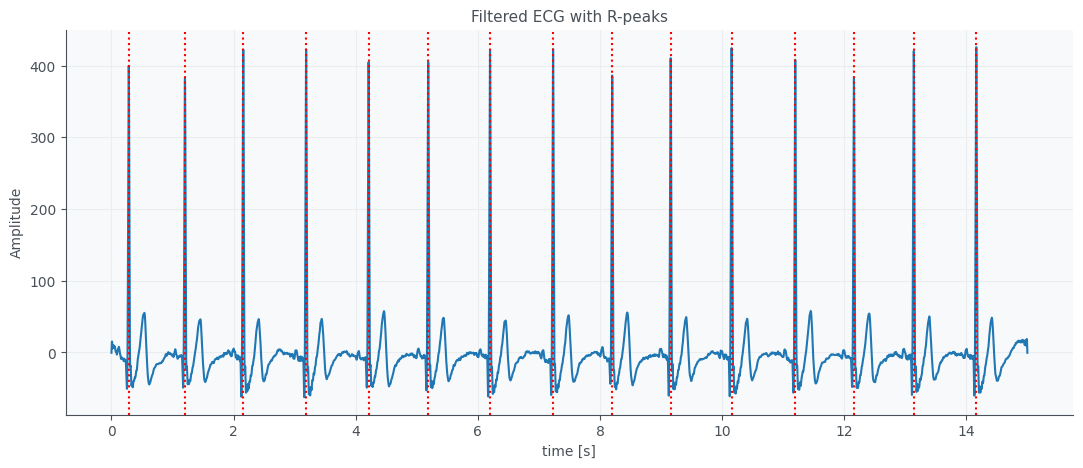

In [14]:
### TODO
filtered_signals = out['filtered']
rpeaks = out['rpeaks']
t = np.arange(len(filtered_signals)) / SAMPLING_RATE

plt.figure(figsize=(13,5))
plt.plot(t, filtered_signals)

# mark R-peaks
for r in rpeaks:
    plt.axvline(x=r/SAMPLING_RATE, color='r', ls=':')

plt.xlabel('time [s]')
plt.ylabel('Amplitude')
plt.title('Filtered ECG with R-peaks')
plt.show()

**Task 7** (5 pts): Let's install the NeuroKit2 library.

In [15]:
!pip install neurokit2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 708.4/708.4 kB 12.2 MB/s eta 0:00:00


**Task 8** (20 pts): Detect P Q S T Peaks using Neurokit.

In [16]:
# We know the R spikes now but what about P Q S T waves?
# TODO Can you use nk.ecg_delineate to detect them in the unfiltred signal?
# Hint: Look at the tutorial: https://neuropsychology.github.io/NeuroKit/examples/ecg_delineate/ecg_delineate.html
# Hint 2: The plot will have blue, orange, green, and red circles :)
# Hint 3: rpeaks were detected above from biosppy's ecg.ecg method
import neurokit2 as nk
#_, waves_peak = nk.ecg_delineate(signal, rpeaks, sampling_rate=SAMPLING_RATE, method="peak")

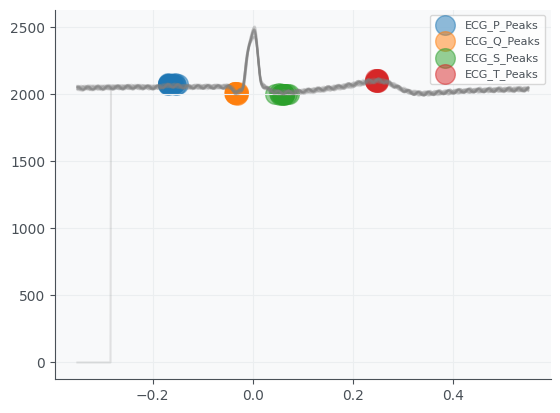

In [17]:
_, waves_peak = nk.ecg_delineate(signal,
                                 rpeaks,
                                 sampling_rate=SAMPLING_RATE,
                                 show=True,
                                 show_type='peaks')

In [ ]:
# TODO Does the detection work well?

R and T waves are consistently detected across most heartbeats. However, the P and S peaks show less alignment in the overlay plot.

**Task 9** (10 pts): Use the sleepecg library to find the R Peaks.

In [18]:
# We have the R spikes/peaks now from Biosppy from above but there is another
# library called sleepecg.
# TODO Please install it and run the rpeak detection!
# Docs: https://sleepecg.readthedocs.io/en/stable/
!pip install sleepecg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.6/419.6 kB 5.4 MB/s eta 0:00:00


In [19]:
# TODO Do Biosppy and sleepecg give different rpeaks? Please calculate the MSE!
from sleepecg import detect_heartbeats
rpeaks_secg = detect_heartbeats(signal, fs=SAMPLING_RATE)

In [20]:
np.mean((rpeaks_secg - rpeaks)**2)

np.float64(0.2)

Some peaks are different but the difference between these two methods is not quite big.

**Bonus Task** (33 pts): Detect P Q S T Peaks for the full signal before and after filtering.

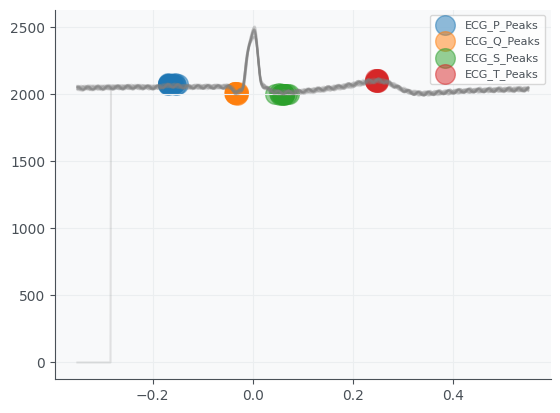

In [21]:
# TODO As above use the nk.ecg_delineate function to detect peaks for the whole signal
_, waves_peak = nk.ecg_delineate(signal,
                                 rpeaks,
                                 sampling_rate=SAMPLING_RATE,
                                 show=True,
                                 show_type='peaks')

In [28]:
# TODO Let's filter the signal and see if the detection improves.
# Hint: You can use nk.signal_filter to define a bandpass.
# Hint 2: Which lowcut and highcut frequencies work well? Play with it :)
# Hint 3: You don't need to re-calculate the rpeaks since they are pretty accurate in general.
ecg_f1 = nk.signal_filter(signal, sampling_rate=SAMPLING_RATE, lowcut=0.5, highcut=45)
ecg_f2 = nk.signal_filter(signal, sampling_rate=SAMPLING_RATE, lowcut=0.5, highcut=40)
ecg_f3 = nk.signal_filter(signal, sampling_rate=SAMPLING_RATE, lowcut=1, highcut=40)
ecg_f4 = nk.signal_filter(signal, sampling_rate=SAMPLING_RATE, lowcut=5, highcut=15)
ecg_f5 = nk.signal_filter(signal, sampling_rate=SAMPLING_RATE, lowcut=3, highcut=30)

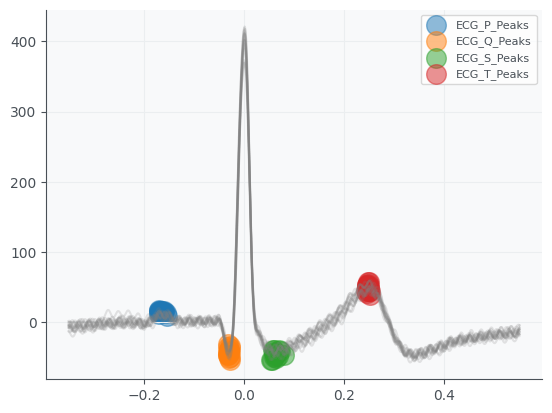

In [36]:
_, waves_peak = nk.ecg_delineate(ecg_f1,
                                 rpeaks,
                                 sampling_rate=SAMPLING_RATE,
                                 show=True,
                                 show_type='peaks')

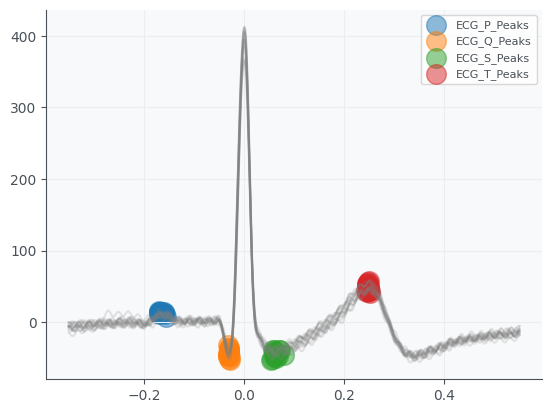

In [25]:
_, waves_peak = nk.ecg_delineate(ecg_f2,
                                 rpeaks,
                                 sampling_rate=SAMPLING_RATE,
                                 show=True,
                                 show_type='peaks')

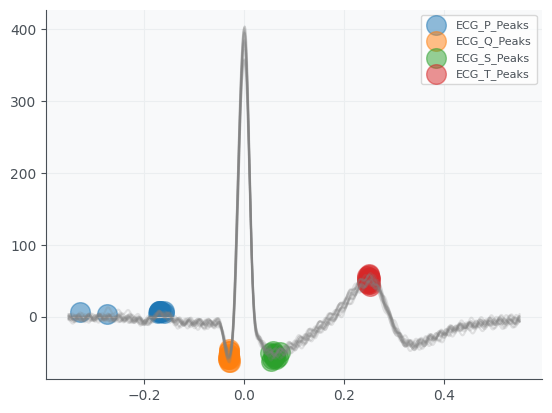

In [26]:
_, waves_peak = nk.ecg_delineate(ecg_f3,
                                 rpeaks,
                                 sampling_rate=SAMPLING_RATE,
                                 show=True,
                                 show_type='peaks')

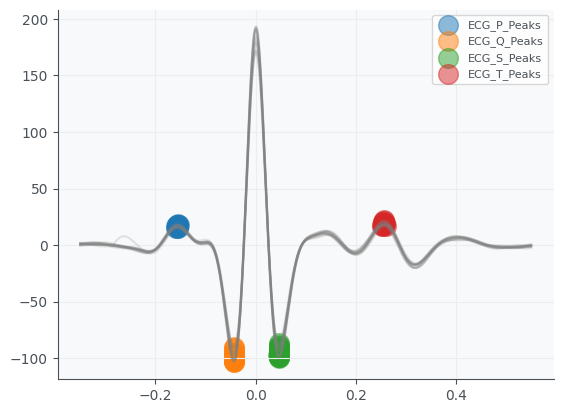

In [27]:
_, waves_peak = nk.ecg_delineate(ecg_f4,
                                 rpeaks,
                                 sampling_rate=SAMPLING_RATE,
                                 show=True,
                                 show_type='peaks')

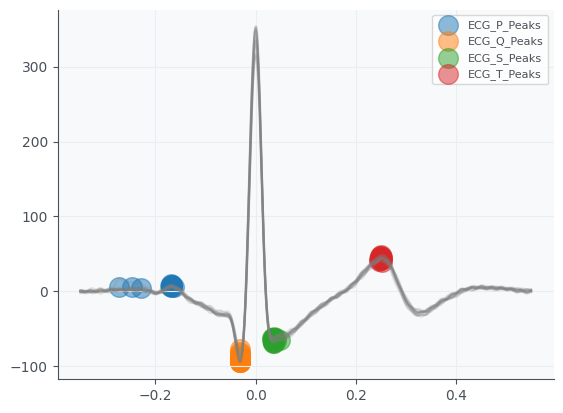

In [29]:
_, waves_peak = nk.ecg_delineate(ecg_f5,
                                 rpeaks,
                                 sampling_rate=SAMPLING_RATE,
                                 show=True,
                                 show_type='peaks')

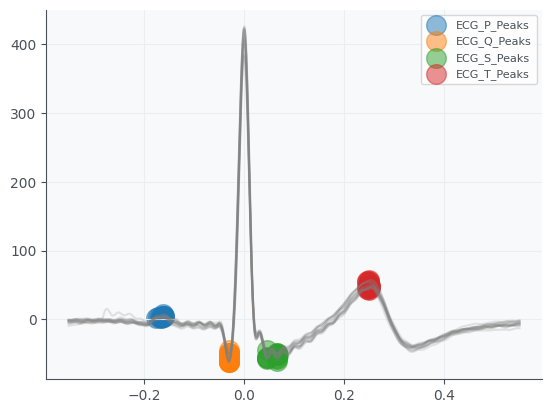

In [44]:
# Finally, run the delineation on the filtered signal from BioSPPY.
_, waves_peak = nk.ecg_delineate(out['filtered'],
                                 rpeaks,
                                 sampling_rate=SAMPLING_RATE,
                                 show=True,
                                 show_type='peaks')

# TODO Which one works the best?
By setting the lowcut and highcut frequencies, the nk.ecg_delineate() function can work better.

In [ ]:
#
# Great job!!
#
#  , ; ,   .-'"""'-.   , ; ,
#  \\|/  .'         '.  \|//
#   \-;-/   ()   ()   \-;-/
#   // ;               ; \\
#  //__; :.         .; ;__\\
# `-----\'.'-.....-'.'/-----'
#        '.'.-.-,_.'.'
#jgs       '(  (..-'
#            '-'
#